In [1]:
import json
import os
import sys
from pathlib import Path
from datetime import datetime
from dotenv import load_dotenv
load_dotenv()

%load_ext autoreload
%autoreload 2

root_path = Path().absolute().parent.parent
sys.path.append(str(root_path))
# print(f"Root path set to: {root_path}")
from eval_agent.user_agent.graph.user_agent_graph import build_graph 

/home/tomas/PUC/TecGraf/conversational_bm/benchmark_nl_databases_conversational_interfaces/functions/query_decomposer.py:37: LangChainDeprecationWarning: The class `LLMChain` was deprecated in LangChain 0.1.17 and will be removed in 1.0. Use :meth:`~RunnableSequence, e.g., `prompt | llm`` instead.
  self.query_analyzer = LLMChain(llm=llm, prompt=self.prompt_builder, verbose=False)


17030
17030


In [2]:

llm = os.getenv("LLM_MODEL")  # e.g., "gpt-4o"
provider = os.getenv("LLM_PROVIDER")  # e.g., "openai"
memory = True # True if it is the experiment of the agent with memory, False if it is the experiment of the agent without memory
database = os.getenv("EXPERIMENT_NAME")
print(f"Running evaluation for LLM: {llm}, Provider: {provider}, Memory: {memory}, Database: {database}")

# Load the experiment dataset
json_file = f'../dataset_generation/dialogue_dataset/{database}_dialogue_dataset.json'
with open(json_file, 'r', encoding='utf-8') as f:
    experiments = json.load(f)


# Build the evaluation graph with the specified memory and environment
eval_graph = build_graph(text_to_sql_agent_memory=memory, env="tec")

experiment_memory = "memory" if memory else "agent_without_memory"
# Defines the name of the file where the results will be saved
evals_filename = f'{llm}-{experiment_memory}-{database}-eval.json'

# If the file already exists, load the experiments already evaluated
if os.path.exists(evals_filename):
    with open(evals_filename, 'r', encoding='utf-8') as f:
        evals = json.load(f)
else:
    evals = []

# Current template configuration (add details of the template used here)
processed_ids = {exp["experiment_id"] for exp in evals}

# Informations to Graph State
model_version = f"{provider}-{llm}"

experiment_type = f"text2sql_evaluation_{experiment_memory}"


Running evaluation for LLM: gpt-4o, Provider: azure, Memory: True, Database: mondial


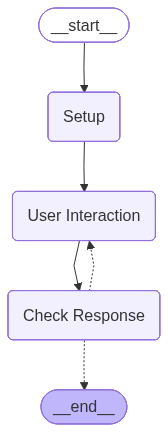

In [3]:
from IPython.display import Image, display


try:
    display(Image(eval_graph.get_graph().draw_mermaid_png()))
except Exception:
    # This requires some extra dependencies and is optional
    pass

In [4]:
# Iterates over all experiments in the dataset
for experiment in experiments['dataset']:
    exp_id = experiment["experiment_id"]

    # Se o experimento já foi avaliado, pula para o próximo
    if exp_id in processed_ids:
        print(f"Pulando experimento {exp_id} já processado.")
        continue

    print(f"Processando experimento {exp_id}...")

    # Invoca a avaliação com as configurações estendidas
    eval_result = eval_graph.invoke({
        "experiment": experiment,
        "max_retries": 2,
        "debug_mode": True,
        "model_version": model_version,
        "experiment_type": experiment_type
    })

    print("Experimento avaliado:\n", eval_result["experiment_eval"])

    # Adiciona o resultado da avaliação junto com o ID do experimento e configuração
    evals.append({
        "experiment_id": exp_id,
        "experiment_config": eval_result.get("experiment_config", {
            "max_retries": 2,
            "model_version": model_version,
            "timestamp": datetime.now().isoformat(),
            "experiment_type": experiment_type
        }),
        "experiment_eval": eval_result["experiment_eval"]
    })

    # Atualiza o arquivo salvando o resultado atual
    with open(evals_filename, 'w', encoding='utf-8') as f:
        json.dump(evals, f, indent=4)

Processando experimento 1...
[NODE] Setup Node entered.
----------------------------------------
[NODE] User Interaction Node entered.
[INFO] Enviando a query para o agente:  Which airports are located in cities with a population greater than 200,000?
Decomposition
['Which airports are located in cities with a population greater than 200,000?']
(17030,)
DFE
Question: Which airports are situated in cities with a population exceeding one million people?
SELECT MONDIAL_AIRPORT.NAME 
FROM MONDIAL_AIRPORT 
JOIN MONDIAL_CITY ON MONDIAL_AIRPORT.CITY = MONDIAL_CITY.NAME 
WHERE MONDIAL_CITY.POPULATION > 1000000

Question: Which airports are situated in regions where the number of people living there is more than one million?
SELECT MONDIAL_AIRPORT.NAME 
FROM MONDIAL_AIRPORT 
JOIN MONDIAL_PROVINCE ON MONDIAL_AIRPORT.PROVINCE = MONDIAL_PROVINCE.NAME 
WHERE MONDIAL_PROVINCE.POPULATION > 1000000

Question: Which cities have a population of more than 200,000 people?
SELECT NAME FROM MONDIAL_CITY WHE

/home/tomas/PUC/TecGraf/conversational_bm/benchmark_nl_databases_conversational_interfaces/venv/lib/python3.10/site-packages/pandas/io/sql.py:761: UserWarning: pandas only support SQLAlchemy connectable(engine/connection) ordatabase string URI or sqlite3 DBAPI2 connectionother DBAPI2 objects are not tested, please consider using SQLAlchemy
  warnings.warn(


[INFO] O resultado da execução foi: {
    "input": "Which airports are located in cities with a population greater than 200,000?",
    "schema_linking": ["airport", "city"],
    "answer": "There are 887 airports located in cities with a population greater than 200,000. Examples include Cheboksary Airport, Pobedilovo Airport, Strigono, Belgorod International Airport, and Chertovitskoye. Would you like details about specific airports or regions?",
    "sql": "SELECT a.name FROM mondial_gpt.airport a JOIN mondial_gpt.city c ON a.city = c.name AND a.country = c.country AND a.province = c.province WHERE c.population > 200000;"
}.

----------------------------------------
[NODE] Check Response Node entered.
[INFO] O resultado da execução foi: {
    "input": "Which airports are located in cities with a population greater than 200,000?",
    "schema_linking": ["airport", "city"],
    "answer": "There are 887 airports located in cities with a population greater than 200,000. Examples include Ch

/home/tomas/PUC/TecGraf/conversational_bm/benchmark_nl_databases_conversational_interfaces/venv/lib/python3.10/site-packages/pandas/io/sql.py:761: UserWarning: pandas only support SQLAlchemy connectable(engine/connection) ordatabase string URI or sqlite3 DBAPI2 connectionother DBAPI2 objects are not tested, please consider using SQLAlchemy
  warnings.warn(
/home/tomas/PUC/TecGraf/conversational_bm/benchmark_nl_databases_conversational_interfaces/venv/lib/python3.10/site-packages/pandas/io/sql.py:761: UserWarning: pandas only support SQLAlchemy connectable(engine/connection) ordatabase string URI or sqlite3 DBAPI2 connectionother DBAPI2 objects are not tested, please consider using SQLAlchemy
  warnings.warn(


True cols: Index(['NAME', 'IATACODE'], dtype='object')
Adj. True cols: Index(['NAME'], dtype='object')
Predicted cols: Index(['NAME'], dtype='object')
Adj. Predicted cols: Index(['NAME'], dtype='object')
[Conditional Edge] Continuamos a avaliação? True
----------------------------------------
[NODE] User Interaction Node entered.
[INFO] Enviando a query para o agente:  What are the elevation levels of these airports?
Decomposition
['What are the elevation levels of airports located in cities with a population greater than 200,000?', 'Quais são os níveis de elevação dos aeroportos?', 'Quais cidades têm uma população maior que 200.000?', 'Quais aeroportos estão localizados nas cidades identificadas com população maior que 200.000?']
(17030,)
(17030,)
(17030,)
(17030,)
DFE
Question: What is the middle elevation of airports where the size of the regions is larger than 100,000?
SELECT MEDIAN(ELEVATION) 
FROM MONDIAL_AIRPORT 
WHERE PROVINCE IN (
    SELECT NAME 
    FROM MONDIAL_PROVINCE 
  

...

Decomposition
['Rank the seas by their area in descending order.', 'Qual é a área de cada mar?', 'Qual é o nome de cada mar?']
(17030,)
(17030,)
(17030,)
DFE
Question: different sizes areas seas
SELECT DISTINCT AREA FROM MONDIAL_SEA

Question: Which seas have an area larger than one million square kilometers in the table that lists information about seas?
SELECT NAME, AREA FROM MONDIAL_SEA WHERE AREA > 1000000

Question: seas known areas
SELECT NAME, AREA FROM MONDIAL_SEA WHERE AREA IS NOT NULL

Question: Which seas have an area larger than 100,000 square kilometers in the database that lists information about different bodies of water?
SELECT NAME 
FROM MONDIAL_SEA 
WHERE AREA > 100000

Question: Which seas have an area larger than 500,000 and cover 100% of their respective regions?
SELECT MS.NAME
FROM MONDIAL_SEA MS
JOIN MONDIAL_ENCOMPASSES ME ON MS.NAME = ME.COUNTRY
WHERE MS.AREA > 500000 AND ME.PERCENTAGE = 100

Question: What are the different sizes of the areas in the sea informa

/home/tomas/PUC/TecGraf/conversational_bm/benchmark_nl_databases_conversational_interfaces/venv/lib/python3.10/site-packages/pandas/io/sql.py:761: UserWarning: pandas only support SQLAlchemy connectable(engine/connection) ordatabase string URI or sqlite3 DBAPI2 connectionother DBAPI2 objects are not tested, please consider using SQLAlchemy
  warnings.warn(


[INFO] O resultado da execução foi: {
    "input": "Rank the seas by their area in descending order.",
    "schema_linking": ["mondial_gpt.sea"],
    "answer": "The seas ranked by area are: Coral Sea (4,791,000 sq km), Arabian Sea (3,862,000 sq km), South China Sea (3,500,000 sq km), Caribbean Sea (2,754,000 sq km), Mediterranean Sea (2,500,000 sq km). If you'd like to know the rank of a specific sea, let me know!",
    "sql": "SELECT name, area FROM mondial_gpt.sea WHERE area IS NOT NULL ORDER BY area DESC"
}.

----------------------------------------
[NODE] Check Response Node entered.
[INFO] O resultado da execução foi: {
    "input": "Rank the seas by their area in descending order.",
    "schema_linking": ["mondial_gpt.sea"],
    "answer": "The seas ranked by area are: Coral Sea (4,791,000 sq km), Arabian Sea (3,862,000 sq km), South China Sea (3,500,000 sq km), Caribbean Sea (2,754,000 sq km), Mediterranean Sea (2,500,000 sq km). If you'd like to know the rank of a specific sea, 

/home/tomas/PUC/TecGraf/conversational_bm/benchmark_nl_databases_conversational_interfaces/venv/lib/python3.10/site-packages/pandas/io/sql.py:761: UserWarning: pandas only support SQLAlchemy connectable(engine/connection) ordatabase string URI or sqlite3 DBAPI2 connectionother DBAPI2 objects are not tested, please consider using SQLAlchemy
  warnings.warn(
/home/tomas/PUC/TecGraf/conversational_bm/benchmark_nl_databases_conversational_interfaces/venv/lib/python3.10/site-packages/pandas/io/sql.py:761: UserWarning: pandas only support SQLAlchemy connectable(engine/connection) ordatabase string URI or sqlite3 DBAPI2 connectionother DBAPI2 objects are not tested, please consider using SQLAlchemy
  warnings.warn(


[AI as JUDGE sql query correctness] Result: True with 0.6791783321527689 of confidence.
[INFO] A avaliação para esse turno foi:  {'interaction_id': 3, 'original_intent': 'Sort the seas by their area in descending order.', 'total_retries_needed': 0, 'success_without_retry': True, 'turns': [{'user_query': 'Can you rank the seas by their area?', 'agent_reply': "The seas ranked by area are: Coral Sea (4,791,000 sq km), Arabian Sea (3,862,000 sq km), South China Sea (3,500,000 sq km), Caribbean Sea (2,754,000 sq km), Mediterranean Sea (2,500,000 sq km). If you'd like to know the rank of a specific sea, let me know!", 'evaluation': {'text_to_sql_input': 'Rank the seas by their area in descending order.', 'user_intention': 'Sort the seas by their area in descending order.', 'recall': 0.0, 'alignment': True, 'correctness': False, 'expected_sql': 'SELECT Name, Area FROM MONDIAL_SEA ORDER BY Area DESC', 'generated_sql': 'SELECT name, area FROM mondial_gpt.sea WHERE area IS NOT NULL ORDER BY area